# Config & Import

In [ ]:
import numpy as np
from scipy.signal import savgol_filter, medfilt, detrend
import os, sys
import matplotlib.pyplot as plt

# ===== IMPORTANT CONFIGURATION VARIABLES =====
input_dataset_type = "raw"
output_dataset_type = "preprocessed"
dataset_split = 'training'  # can be 'training', 'validation', 'test'

# Function to find project root
def find_project_root(name='Bambino', start=None):
    if start is None:
        start = os.getcwd()
    parent_dir = start
    while True:
        if os.path.basename(parent_dir) == name:
            return parent_dir
        new_parent = os.path.dirname(parent_dir)
        if new_parent == parent_dir:
            return None
        parent_dir = new_parent

PROJECT_ROOT = find_project_root('Bambino')
print('Detected project root:', PROJECT_ROOT)

# Attempt to import config & datasets if project is found
dataset = None
dataset_original = None
if PROJECT_ROOT:
    try:
        sys.path.append(PROJECT_ROOT)
        from config import settings as utils
        from DataUtils.BoaOpenFaceDataset import BoaOpenFaceDataset
        print('Imported project modules successfully.')
        # try to load a sample split (this will only work if utils paths are correct locally)
        try:
            in_path = utils.get_dataset_path(input_dataset_type,
                                            getattr(utils, f'{dataset_split}_filename'))
            print('Attempting to load dataset from:', in_path)
            dataset = BoaOpenFaceDataset.load_dataset(in_path, modalities=None)
            dataset_original = BoaOpenFaceDataset.load_dataset(in_path, modalities=None)
            print('Dataset loaded:', type(dataset), 'instances:', len(dataset.instances))
            out_path = utils.get_dataset_path(output_dataset_type, getattr(utils, f'{dataset_split}_filename'))
            print('Output path for processed dataset:', out_path)
        except Exception as e:
            print('Could not load dataset from project paths (this is OK). Error:', e)
            dataset = None
    except Exception as e:
        print('Could not import project modules (this is OK). Error:', e)
        dataset = None


Detected project root: /home/phd2/Scrivania/CorsoRepo/Bambino
Imported project modules successfully.
Attempting to load dataset from: /home/phd2/Scrivania/CorsoRepo/Bambino/data/raw/training_set.pt
Dataset loaded: <class 'DataUtils.BoaOpenFaceDataset.BoaOpenFaceDataset'> instances: 619
Output path for processed dataset: /home/phd2/Scrivania/CorsoRepo/Bambino/data/preprocessed/training_set.pt


In [ ]:
# Inspect dataset structure
if dataset is not None:
    print('\nInspecting dataset structure:')
    print('AGE_GROUPS =', dataset.AGE_GROUPS)
    print('AGE_GROUPS_BOA =', dataset.AGE_GROUPS_BOA)
    print('FRAME_RATE =', dataset.FRAME_RATE)
    print('MIN_SEQUENCE_LENGTH =', dataset.MIN_SEQUENCE_LENGTH)
    print('SEX_GROUPS =', dataset.SEX_GROUPS)
    print('SPEAKER_GROUPS =', dataset.SPEAKER_GROUPS)
    print('TRIAL_ID_GROUPS =', dataset.TRIAL_ID_GROUPS)
    print('TRIAL_TYPES =', dataset.TRIAL_TYPES)

    print('\nInspecting first instance:')

    for inst in dataset.instances[:1]:
        print('Age:', inst.age)
        print('Sex:', inst.sex)
        print('gaze_info:', inst.gaze_info.shape)
        print('head_info:', inst.head_info.shape)
        print('face_info:', inst.face_info.shape)
        print('audio_type:', inst.audio)
        print('pt_id:', inst.pt_id)
        print('Speaker:', inst.speaker)
        print('Trial_id:', inst.trial_id)
        print('Trial_type:', inst.trial_type)

else:
    print('Dataset not loaded; cannot inspect structure.')


Inspecting dataset structure:
AGE_GROUPS = ['7-11', '12-18', '19-24']
AGE_GROUPS_BOA = ['[3-5.5)', '[5.5-7]']
FRAME_RATE = 25
MIN_SEQUENCE_LENGTH = 300
SEX_GROUPS = ['Female', 'Male']
SPEAKER_GROUPS = ['Left', 'Right']
TRIAL_ID_GROUPS = ['0-30th percentiles', '30-70th percentiles', '70-100th percentiles']
TRIAL_TYPES = ['control', 'stimulus']

Inspecting first instance:
Age: 5.65
Sex: 1
gaze_info: (250, 8)
head_info: (250, 13)
face_info: (250, 17)
audio_type: other personalised
pt_id: bam1_001
Speaker: 0
Trial_id: 1
Trial_type: 1


In [7]:
# Print some statistics: mean age with percentiles, sex distribution, number of instances, etc.
if dataset is not None:
    ages = [inst.age for inst in dataset.instances if inst.age is not None]
    if ages:
        mean_age = np.mean(ages)
        p25 = np.percentile(ages, 5)
        p50 = np.percentile(ages, 50)
        p75 = np.percentile(ages, 95)
        print(f'\nAge statistics: Mean={mean_age:.2f}, 5th percentile={p25}, Median={p50}, 95th percentile={p75}')
    else:
        print('\nNo age data available.')
    
    # consider the pt_id to count unique subjects and print the total per sex and the total number of unique subjects
    pt_ids = [inst.pt_id for inst in dataset.instances if inst.pt_id is not None]
    unique_pt_ids = np.unique(pt_ids)
    print(f'\nTotal number of unique subjects: {len(unique_pt_ids)}')
    
    sexes = [inst.sex for inst in dataset.instances if inst.sex is not None]
    if sexes:
        unique, counts = np.unique(sexes, return_counts=True)
        print('\nNumber of subjects per sex:')
        for u, c in zip(unique, counts):
            print(f'{u}: {c}')
    else:
        print('\nNo sex data available.')
    
    print(f'\nTotal number of instances: {len(dataset.instances)}')



Age statistics: Mean=5.49, 5th percentile=3.65, Median=5.59, 95th percentile=7.26

Total number of unique subjects: 32

Number of subjects per sex:
0: 345
1: 274

Total number of instances: 619


# Helpers

In [26]:
def _preprocess_channel(data: np.ndarray,
                        window_length: int = 11,
                        polyorder: int = 2,
                        median_kernel: int = 5) -> np.ndarray:
    """
    Applicazione di detrend, Savitzky-Golay smoothing e filtro mediano.

    Args:
        data: array 2D (timesteps x features)
    Returns:
        Processed array same shape.
    """
    # 1) Detrending per colonna
    data_dt = detrend(data, axis=0)

    # 2) Savitzky-Golay smoothing
    # window_length deve essere odd e <= num timesteps
    wl = min(window_length, data_dt.shape[0] // 2 * 2 - 1)
    if wl < polyorder + 2:
        wl = polyorder + 2 if (polyorder + 2) % 2 == 1 else polyorder + 3
    data_sg = savgol_filter(data_dt, window_length=wl, polyorder=polyorder, axis=0)

    # 3) Median filter lungo ogni feature
    # medfilt richiede kernel size odd scalar
    data_med = np.stack([medfilt(data_sg[:, i], kernel_size=median_kernel)
                         for i in range(data_sg.shape[1])], axis=1)

    return data_med

"""
Savitzky_Golay window
--> Deve essere odd e significativamente più piccolo di 250. 
--> Tipicamente si usa tra il 5% e il 15% della lunghezza della finestra, quindi tra 13 e 37 campioni.
--> prendo range 21-31
"""

def preprocess_gaze(gaze: np.ndarray) -> np.ndarray:
    """Preprocessing specifico per gaze_info"""
    return _preprocess_channel(gaze, window_length=21, polyorder=3, median_kernel=7)


def preprocess_head(head: np.ndarray) -> np.ndarray:
    """Preprocessing specifico per head_info"""
    return _preprocess_channel(head, window_length=25, polyorder=3, median_kernel=5)


def preprocess_face(face: np.ndarray) -> np.ndarray:
    """Preprocessing specifico per face_info"""
    return _preprocess_channel(face, window_length=31, polyorder=3, median_kernel=7)


# Main

In [27]:
print(dataset.instances[0]) # è un oggetto "OpenFaceInstance"
print(dataset.instances[0].age)
print(dataset.instances[0].gaze_info.shape)

print(dataset_original.instances[0].gaze_info.shape)

5.65
(250, 8)
(250, 8)


In [28]:
# %% Apply preprocessing to all instances (in-memory)
print('Applying preprocessing to all instances')
for inst in dataset.instances:
    inst.gaze_info = preprocess_gaze(inst.gaze_info)
    inst.head_info = preprocess_head(inst.head_info)
    inst.face_info = preprocess_face(inst.face_info)
print('Done.')

Applying preprocessing to all instances
Done.


In [29]:
# %% Optional: save processed dataset
import pickle

SAVE_PROCESSED = True  # set True to save to disk

if SAVE_PROCESSED:
    with open(out_path, 'wb') as f:
        pickle.dump(dataset, f)
    print(f'Saved processed dataset to {out_path}')
else:
    print('SAVE_PROCESSED is False -> not saving. Set SAVE_PROCESSED = True to enable saving.')

Saved processed dataset to /home/phd2/Scrivania/CorsoRepo/Bambino/data/preprocessed/training_set.pt


# Visualization

Visualizing some examples, pre and post processing


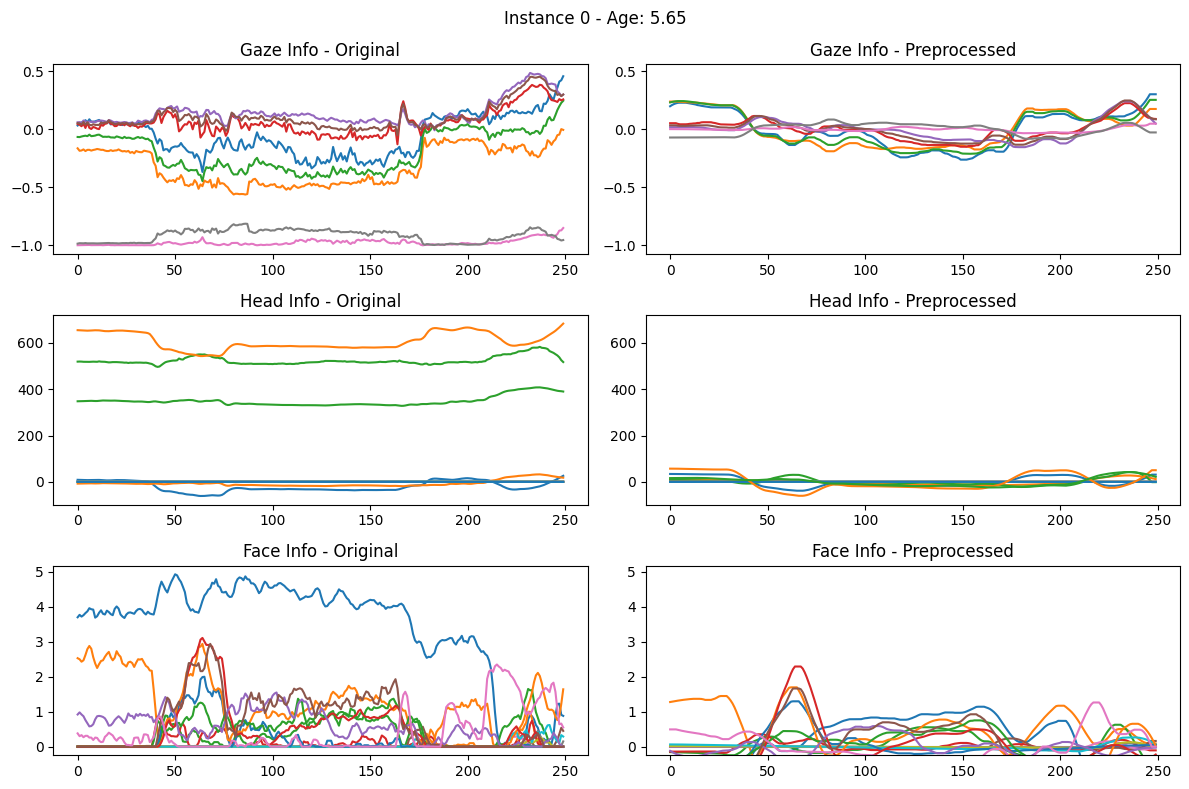

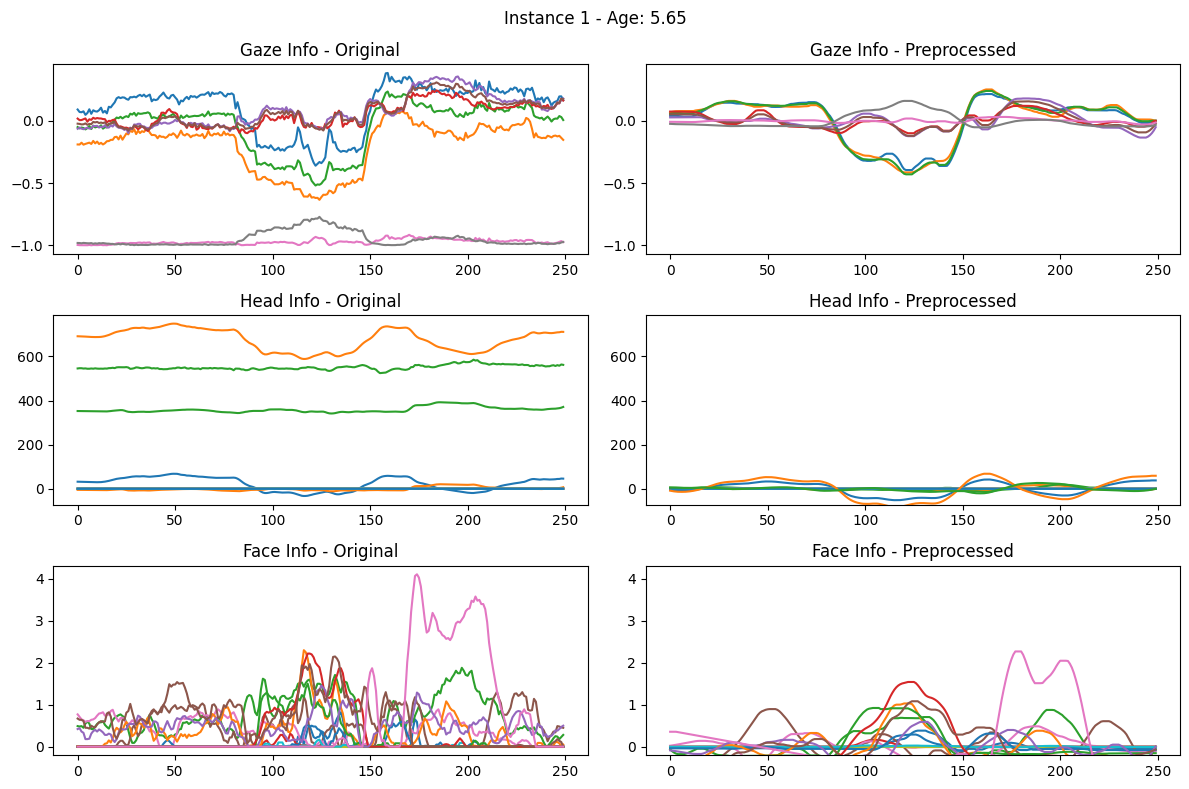

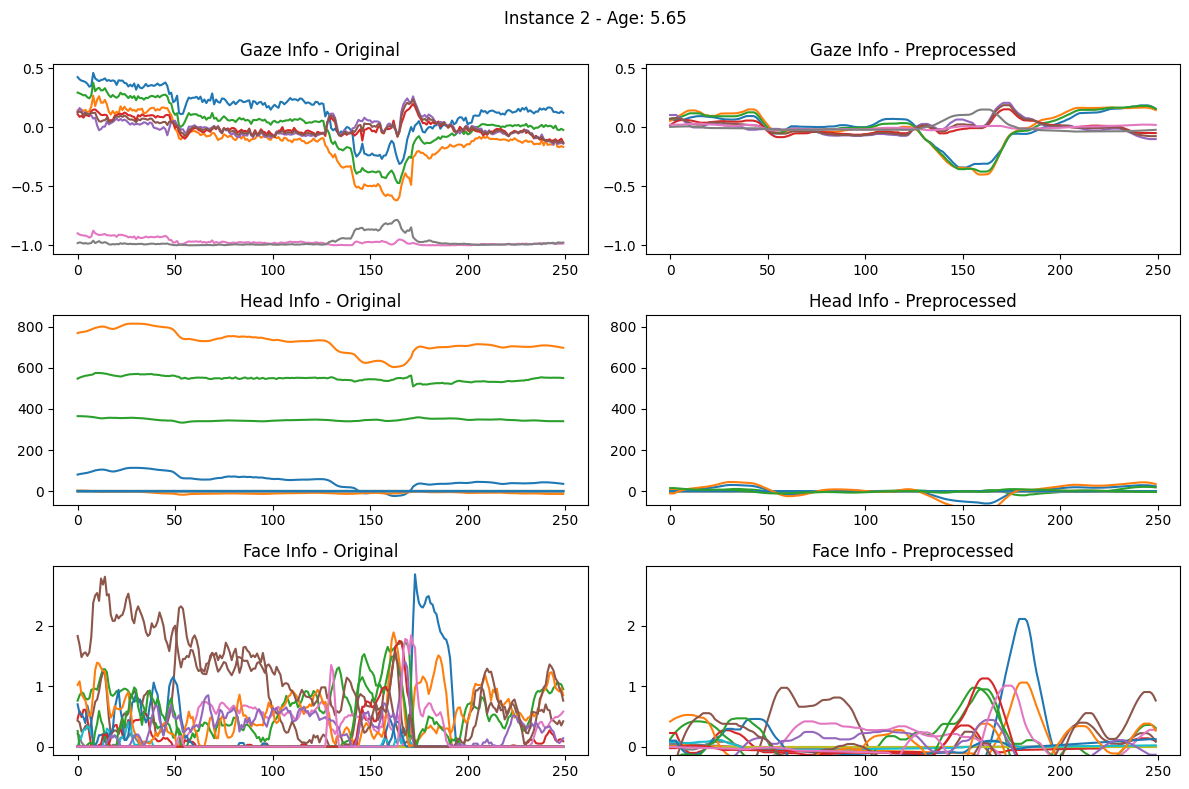

In [30]:
# Visualize some examples, pre and post processing
# same y scale for comparison
print('Visualizing some examples, pre and post processing')
num_examples = 3
for i in range(num_examples):
    fig, axs = plt.subplots(3, 2, figsize=(12, 8))
    fig.suptitle(f'Instance {i} - Age: {dataset.instances[i].age}')

    # Gaze info
    axs[0, 0].set_title('Gaze Info - Original')
    axs[0, 0].plot(dataset_original.instances[i].gaze_info)
    axs[0, 1].set_title('Gaze Info - Preprocessed')
    axs[0, 1].plot(dataset.instances[i].gaze_info)
    axs[0, 1].set_ylim(axs[0, 0].get_ylim())

    # Head info
    axs[1, 0].set_title('Head Info - Original')
    axs[1, 0].plot(dataset_original.instances[i].head_info)
    axs[1, 1].set_title('Head Info - Preprocessed')
    axs[1, 1].plot(dataset.instances[i].head_info)
    axs[1, 1].set_ylim(axs[1, 0].get_ylim())

    # Face info
    axs[2, 0].set_title('Face Info - Original')
    axs[2, 0].plot(dataset_original.instances[i].face_info)
    axs[2, 1].set_title('Face Info - Preprocessed')
    axs[2, 1].plot(dataset.instances[i].face_info)
    axs[2, 1].set_ylim(axs[2, 0].get_ylim())

    plt.tight_layout()
    plt.show()